# patent analysis for summit slides  

This notebook contains the **minimum required code** to regenerate the figures created in cells 60-62 of the original analysis notebook.

It rebuilds all dependent variables from raw data so the plots run end-to-end in a fresh kernel.

In [ ]:
import ast
from collections import Counter
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 400

DATA_PATH = Path('../data/patent/df_with_iso_aggressive.csv')
IPC_PATH = Path('../data/patent/ipc_hierarchy.csv')
MACRO_LEBELS_PATH = Path.cwd().parents[0]/"file/paten_rcdc_macro/cluster_label_summary_louvain.csv"


if not DATA_PATH.exists():
    raise FileNotFoundError(f'Missing input file: {DATA_PATH}')

df_patent = pd.read_csv(DATA_PATH)
df_patent['assignee_countries']=[ast.literal_eval(x) if pd.notna(x) else [] for x in df_patent['assignee_countries']]

df_ipc = pd.read_csv(IPC_PATH)
section_dict = {row['symbol']: row['title'].replace('/ ','') for _, row in df_ipc.loc[df_ipc['level']=='Section'].iterrows()}
class_dict = {row['symbol']: row['title'].replace('/ ','') for _, row in df_ipc.loc[df_ipc['level']=='Class'].iterrows()}
subclass_dict = {row['symbol']: row['title'].replace('/ ','') for _, row in df_ipc.loc[df_ipc['level']=='Subclass'].iterrows()}

ipc_dict = {**section_dict, **class_dict, **subclass_dict}
ipc_dict = {x:y.lower() for x,y in ipc_dict.items()}

# extract IPC hierarchy levels from symbol
df_ipc['section']= df_ipc['symbol'].str[0]
df_ipc['class']= df_ipc['symbol'].str.extract(r'^([A-Z]\d{2})')[0]
df_ipc['subclass']= df_ipc['symbol'].str.extract(r'^([A-Z]\d{2}[A-Z])')[0]
df_ipc['main_group'] = df_ipc['symbol'].str.extract(r'^([A-Z]\d{2}[A-Z]\d{4})')[0]
df_ipc['number_level_1'] = df_ipc['symbol'].str.extract(r'^[A-Z]\d{2}[A-Z](\d{4})')[0]
df_ipc['number_level_2'] = df_ipc['symbol'].str.extract(r'^[A-Z]\d{2}[A-Z]\d{4}(\d{6})')[0]
colors_scheme = ['#B80C09', '#D4AF37', '#6E8B3D', '#345995']
title_fontsize = 13
display_chars = 40



import pandas as pd 
from pathlib import Path


cat_col='category_rcdc'
if cat_col=='category_rcdc':
    df_patent[cat_col] = [ast.literal_eval(x) if isinstance(x, str) else [] for x in df_patent[cat_col]]
    cat_dict = {}
    for cats in df_patent[cat_col]:
        for c in cats:
            if isinstance(c, dict) and 'name' in c:
                cat_dict[c['id']] = c['name']
                
df_rcdc_macro_labels = pd.read_csv(MACRO_LEBELS_PATH)
df_rcdc_macro_labels['top_label_names'] = df_rcdc_macro_labels['top_labels'].apply(lambda x: [cat_dict.get(lab, "Unknown") for lab in x.split(';')])

macro_cluster_names = {
    0: "Stem Cell & Regenerative Medicine",
    1: "Biomedical Engineering & Digital Health",
    2: "Aging & Neurodegenerative Disorders",
    3: "Mental Health & Behavioral Disorders",
    4: "Genomic & Precision Medicine",
    5: "Metabolic & Hepatic Disorders",
    6:"Infectious & Rare Disease Research "
}
df_rcdc_macro_labels['cluster_names'] = df_rcdc_macro_labels['community'].map(macro_cluster_names)
top_topic_dict = {x:y.split(";") for x,y in zip(df_rcdc_macro_labels['community'], df_rcdc_macro_labels['all_labels'])}
code_to_macro = {
code: macro
for macro, code_list in top_topic_dict.items()
for code in code_list}


In [2]:
def parse_list_like(value):
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            return parsed if isinstance(parsed, list) else []
        except Exception:
            return []
    return []

def extract_ipc_class_codes(value):
    codes = []
    for item in parse_list_like(value):
        text = str(item).strip().upper()
        if len(text) >= 3 and text[0].isalpha() and text[1:3].isdigit():
            codes.append(text[:3])
    return sorted(set(codes))

def load_world_geometry():
    candidate = Path('/Users/valler/Dropbox/dgg_research/shape_files/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')
    if candidate.exists():
        world = gpd.read_file(candidate)
        world.columns = [c.lower() for c in world.columns]
        return world, 'iso_a3'

    try:
        world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
        world.columns = [c.lower() for c in world.columns]
        return world, 'iso_a3'
    except Exception as exc:
        raise RuntimeError('Could not load world geometry from local shapefile or geopandas datasets.') from exc
    
    
def map_ipcr_code_to_standardized_code(code):
    front_code = code.split('/')[0]
    front_code = front_code[0:4]+f'{int(front_code[4:]):04d}'
    tail_code = code.split('/')[1] if '/' in code else ''
    tail_code = tail_code+'0'*(6-len(tail_code)) if tail_code else ''
    return front_code + ( tail_code if tail_code else '')

def map_ipc_topic_titles(codes):
    titles = []
    for code in codes:
        if code in df_ipc['symbol'].values:
            title = df_ipc.loc[df_ipc['symbol'] == code, 'title'].values[0]
            titles.append(title)
    return titles

def ipc_code_to_top_level(codes,level):
    """
    Given a list of IPC codes, return the corresponding top-level codes (Section, Class, or Subclass).
     - codes: list of IPC codes (e.g., ['A01', 'B23K 26/00'])
     - level: one of 'Section', 'Class', 'Subclass' to specify which top-level code to extract
    Returns: list of top-level codes corresponding to   the input codes
     - For example, if level='Section' and input code is 'A01', it would return 'A'. If level='Class' and input code is 'B23K 26/00', it would return 'B23'. If level='Subclass' and input code is '
    """
    top_codes = []
    for code in codes:
        if code in df_ipc['symbol'].values:
            top_code = df_ipc.loc[df_ipc['symbol'] == code, level].values[0]
            top_codes.append(top_code)
    return top_codes
        


In [3]:
cat_col='category_rcdc'

In [4]:
topcode_to_label = {code: df_rcdc_macro_labels.loc[df_rcdc_macro_labels['community'] == code, 'cluster_names'].values[0] for code in df_rcdc_macro_labels['community']}
topcode_to_label

{0: 'Stem Cell & Regenerative Medicine',
 1: 'Biomedical Engineering & Digital Health',
 2: 'Aging & Neurodegenerative Disorders',
 3: 'Mental Health & Behavioral Disorders',
 4: 'Genomic & Precision Medicine',
 5: 'Metabolic & Hepatic Disorders',
 6: 'Infectious & Rare Disease Research '}

In [5]:
# Filing-status stack inputs (plot a)
status_col = 'filing_status'
filing_status_yearly = (
    df_patent[['publication_year', status_col]]
    .dropna(subset=['publication_year'])
    .groupby(['publication_year', status_col])
    .size()
    .reset_index(name='count')
)
pivot_df = filing_status_yearly.pivot(index='publication_year', columns=status_col, values='count').fillna(0)
pivot_df = pivot_df.sort_index()
totals = pivot_df.sum(axis=1)

status_colors = {
    'Application Pending': '#4C72B0',
    'Application Ceased': '#8172B2',
    'Active': '#64B5A7',
    'Application Withdrawn': '#CCB974',
    'Granted Patent Expired': '#DD8452',
    'Application Granted': '#55A868',
    'Application Abandoned': '#C44E52',
    'Application': '#4C72B0'
}

# Country counts + world merge (plot from cell 60 and plot b)
counter = Counter()

for countries in df_patent['assignee_countries']:
    if isinstance(countries, list):
        for c in countries:
            if isinstance(c, str):
                counter[c.upper()] += 1

country_count = dict(counter)

# convert to DataFrame
country_df = (
    pd.DataFrame(country_count.items(), columns=['iso2', 'count'])
      .sort_values('count', ascending=False)
      .reset_index(drop=True)
)
try:
    import pycountry

    def iso2_to_iso3(code):
        c = pycountry.countries.get(alpha_2=code)
        return c.alpha_3 if c else None
except Exception:
    def iso2_to_iso3(code):
        fallback = {'UK': 'GBR', 'GB': 'GBR'}
        return fallback.get(code)

country_df['iso3'] = country_df['iso2'].apply(iso2_to_iso3)
country_df = country_df.dropna(subset=['iso3'])

world, world_key = load_world_geometry()
world_patents = world.merge(country_df, how='left', left_on=world_key, right_on='iso3')

# Topic inputs (plots c and d)
if cat_col =='ipcr':

    df_patent[cat_col] = df_patent[cat_col].fillna('[]').apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])
    df_patent['topics_list_raw']= df_patent[cat_col].apply(lambda codes: [map_ipcr_code_to_standardized_code(c) for c in codes if isinstance(c, str)] if isinstance(codes, list) else [])
    df_patent['topics_list'] = df_patent['topics_list_raw'].apply(map_ipc_topic_titles)
    df_patent['n_topics'] = df_patent['topics_list'].apply(len)

    avg_topics = df_patent['n_topics'].mean()
    median_topics = df_patent['n_topics'].median()

    class_rows = df_ipc[df_ipc['level'].str.lower() == 'class'].copy()
    ipc_dict = {str(r['symbol']).upper(): str(r['title']).lower() for _, r in class_rows.iterrows()}
    topcode_to_label = ipc_dict

    level='class' # section, class, subclass, or main group
    df_patent['top_level_topics'] = df_patent['topics_list_raw'].apply(lambda topics: ipc_code_to_top_level(topics,level))

if cat_col == 'category_rcdc':
    #df_patent[cat_col] = [ast.literal_eval(x) for x in df_patent[cat_col].fillna('[]')]
    df_patent['topics_list'] = [ [m['id'] for m in x] if isinstance(x, list) else [] for x in df_patent[cat_col]]
    df_patent['top_level_topics'] = df_patent['topics_list'].apply(lambda topics: list({code_to_macro.get(code) for code in topics if code in code_to_macro}))
    df_patent['n_topics'] = df_patent['topics_list'].apply(len)
    topcode_to_label = {code: df_rcdc_macro_labels.loc[df_rcdc_macro_labels['community'] == code, 'cluster_names'].values[0] for code in df_rcdc_macro_labels['community']}

avg_topics = df_patent['n_topics'].mean()
median_topics = df_patent['n_topics'].median()

topic_frequency = Counter()
for topics in df_patent['top_level_topics']:
    for code in set(topics):
        topic_frequency[code] += 1


df_with_country = df_patent[df_patent['assignee_countries'].apply(len) > 0].copy()
fractional_country_counts = {}
for _, row in df_with_country.iterrows():
    countries = row['assignee_countries']
    if countries:
        w = 1.0 / len(countries)
        for country in countries:
            if str(country)!= 'None':
                fractional_country_counts[country] = fractional_country_counts.get(country, 0) + w

country_counts_frac = dict(sorted(fractional_country_counts.items(), key=lambda x: x[1], reverse=True))
top_countries = [c for c, _ in list(country_counts_frac.items())[:8]]

country_topic_data = []
for _, row in df_with_country.iterrows():
    countries = row['assignee_countries']
    topics = row['top_level_topics']
    if topics and countries:
        w = 1.0 / len(countries)
        for country in countries:
            for code in set(topics):
                country_topic_data.append({
                    'country': country,
                    'topic_code': code,
                    'topic_label': topcode_to_label.get(code, code),
                    'weight': w
                })
                

df_country_topic = pd.DataFrame(country_topic_data)
topic_by_country = df_country_topic.groupby(['country', 'topic_code', 'topic_label'])['weight'].sum().reset_index(name='count')
top_topic_codes = [code for code, _ in topic_frequency.most_common(8)]
df_viz = topic_by_country[topic_by_country['country'].isin(top_countries) & topic_by_country['topic_code'].isin(top_topic_codes)].copy()
pivot_country_topic = df_viz.pivot_table(index='topic_code', columns='country', values='count', fill_value=0)
pivot_country_topic = pivot_country_topic.reindex(index=top_topic_codes, columns=top_countries, fill_value=0)
pivot_country_topic.rename(columns={'GB': 'UK'}, inplace=True)

In [6]:
topic_short_names_2 = {
    "dyes paints polishes natural resins adhesives compositions not otherwise provided for applications of materials not otherwise provided for":
        "Coatings & Adhesives",

    "electric communication technique":
        "Telecommunications",

    "educating cryptography display advertising seals":
        "Education & Cryptography",

    "optics":
        "Optics",

    "electric elements":
        "Electrical Components",

    "information and communication technology [ict] specially adapted for specific application fields":
        "Applied ICT",

    "combinatorial technology":
        "Combinatorial Technology",

    "agriculture forestry animal husbandry hunting trapping fishing":
        "Agriculture & Forestry",

    "foods, foodstuffs or non-alcoholic beverages preparation, treatment or preservation thereof":
        "Food Processing",

    "sports games amusements":
        "Sports & Entertainment",

    "medical or veterinary science hygiene":
        "Medical & Veterinary Science",

    "computing or calculating counting":
        "Computing & Calculation",

    "measuring testing":
        "Measurement & Testing",

    "biochemistry beer spirits wine vinegar microbiology enzymology mutation or genetic engineering":
        "Biochemistry & Biotechnology",

    "organic chemistry":
        "Organic Chemistry"
}

## Plot 1: Global Distribution of Patent Assignees
This choropleth map shows where assignee occurrences are concentrated.

Interpretation: darker countries indicate more assignee occurrences in the patent data.

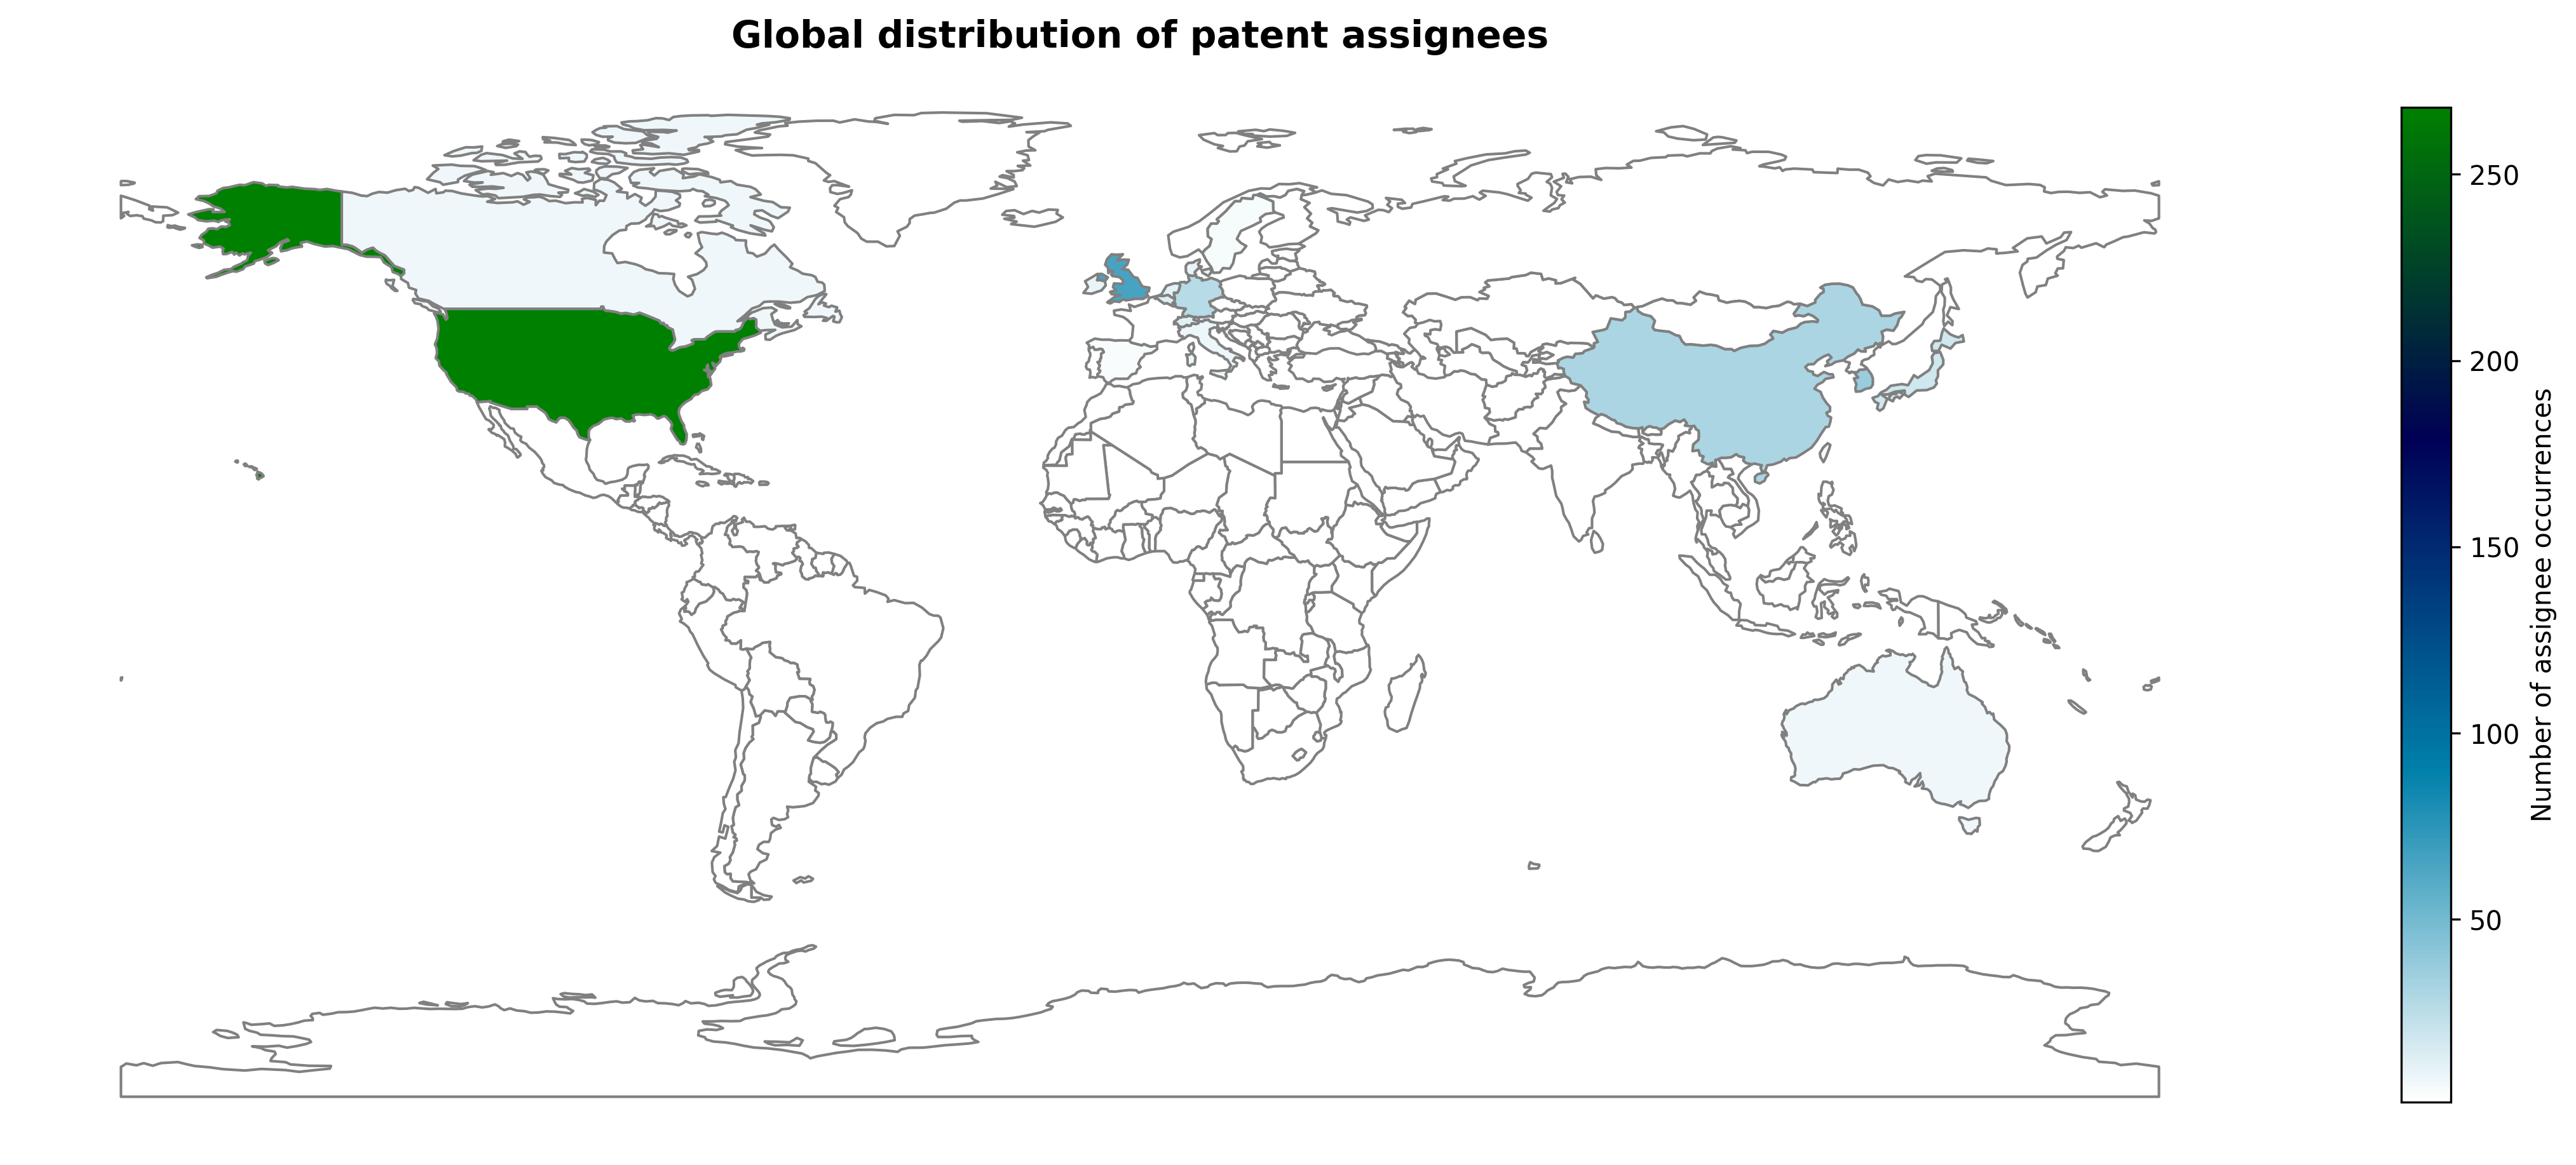

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(15, 9))
world_patents.plot(
    column='count',
    ax=ax,
    legend=True,
    cmap='ocean_r',
    edgecolor='grey',
    missing_kwds={'color': 'white', 'label': 'No patents'},
    legend_kwds={'label': 'Number of assignee occurrences', 'shrink': 0.6}
)
ax.set_title('Global distribution of patent assignees', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('../fig/patent_geo_distribution.png', dpi=400)

## Plot 2-5 : Assembled Patent Dashboard
This dashboard reproduces the 2x2 figure from cell 62:

- **(a)** Stacked bars of filing status over publication years (with segment percentages).
- **(b)** Top countries by assignee occurrences.
- **(c)** Distribution of number of IPC class topics per patent (mean and median marked).
- **(d)** Heatmap of country-topic composition using fractional country weighting.

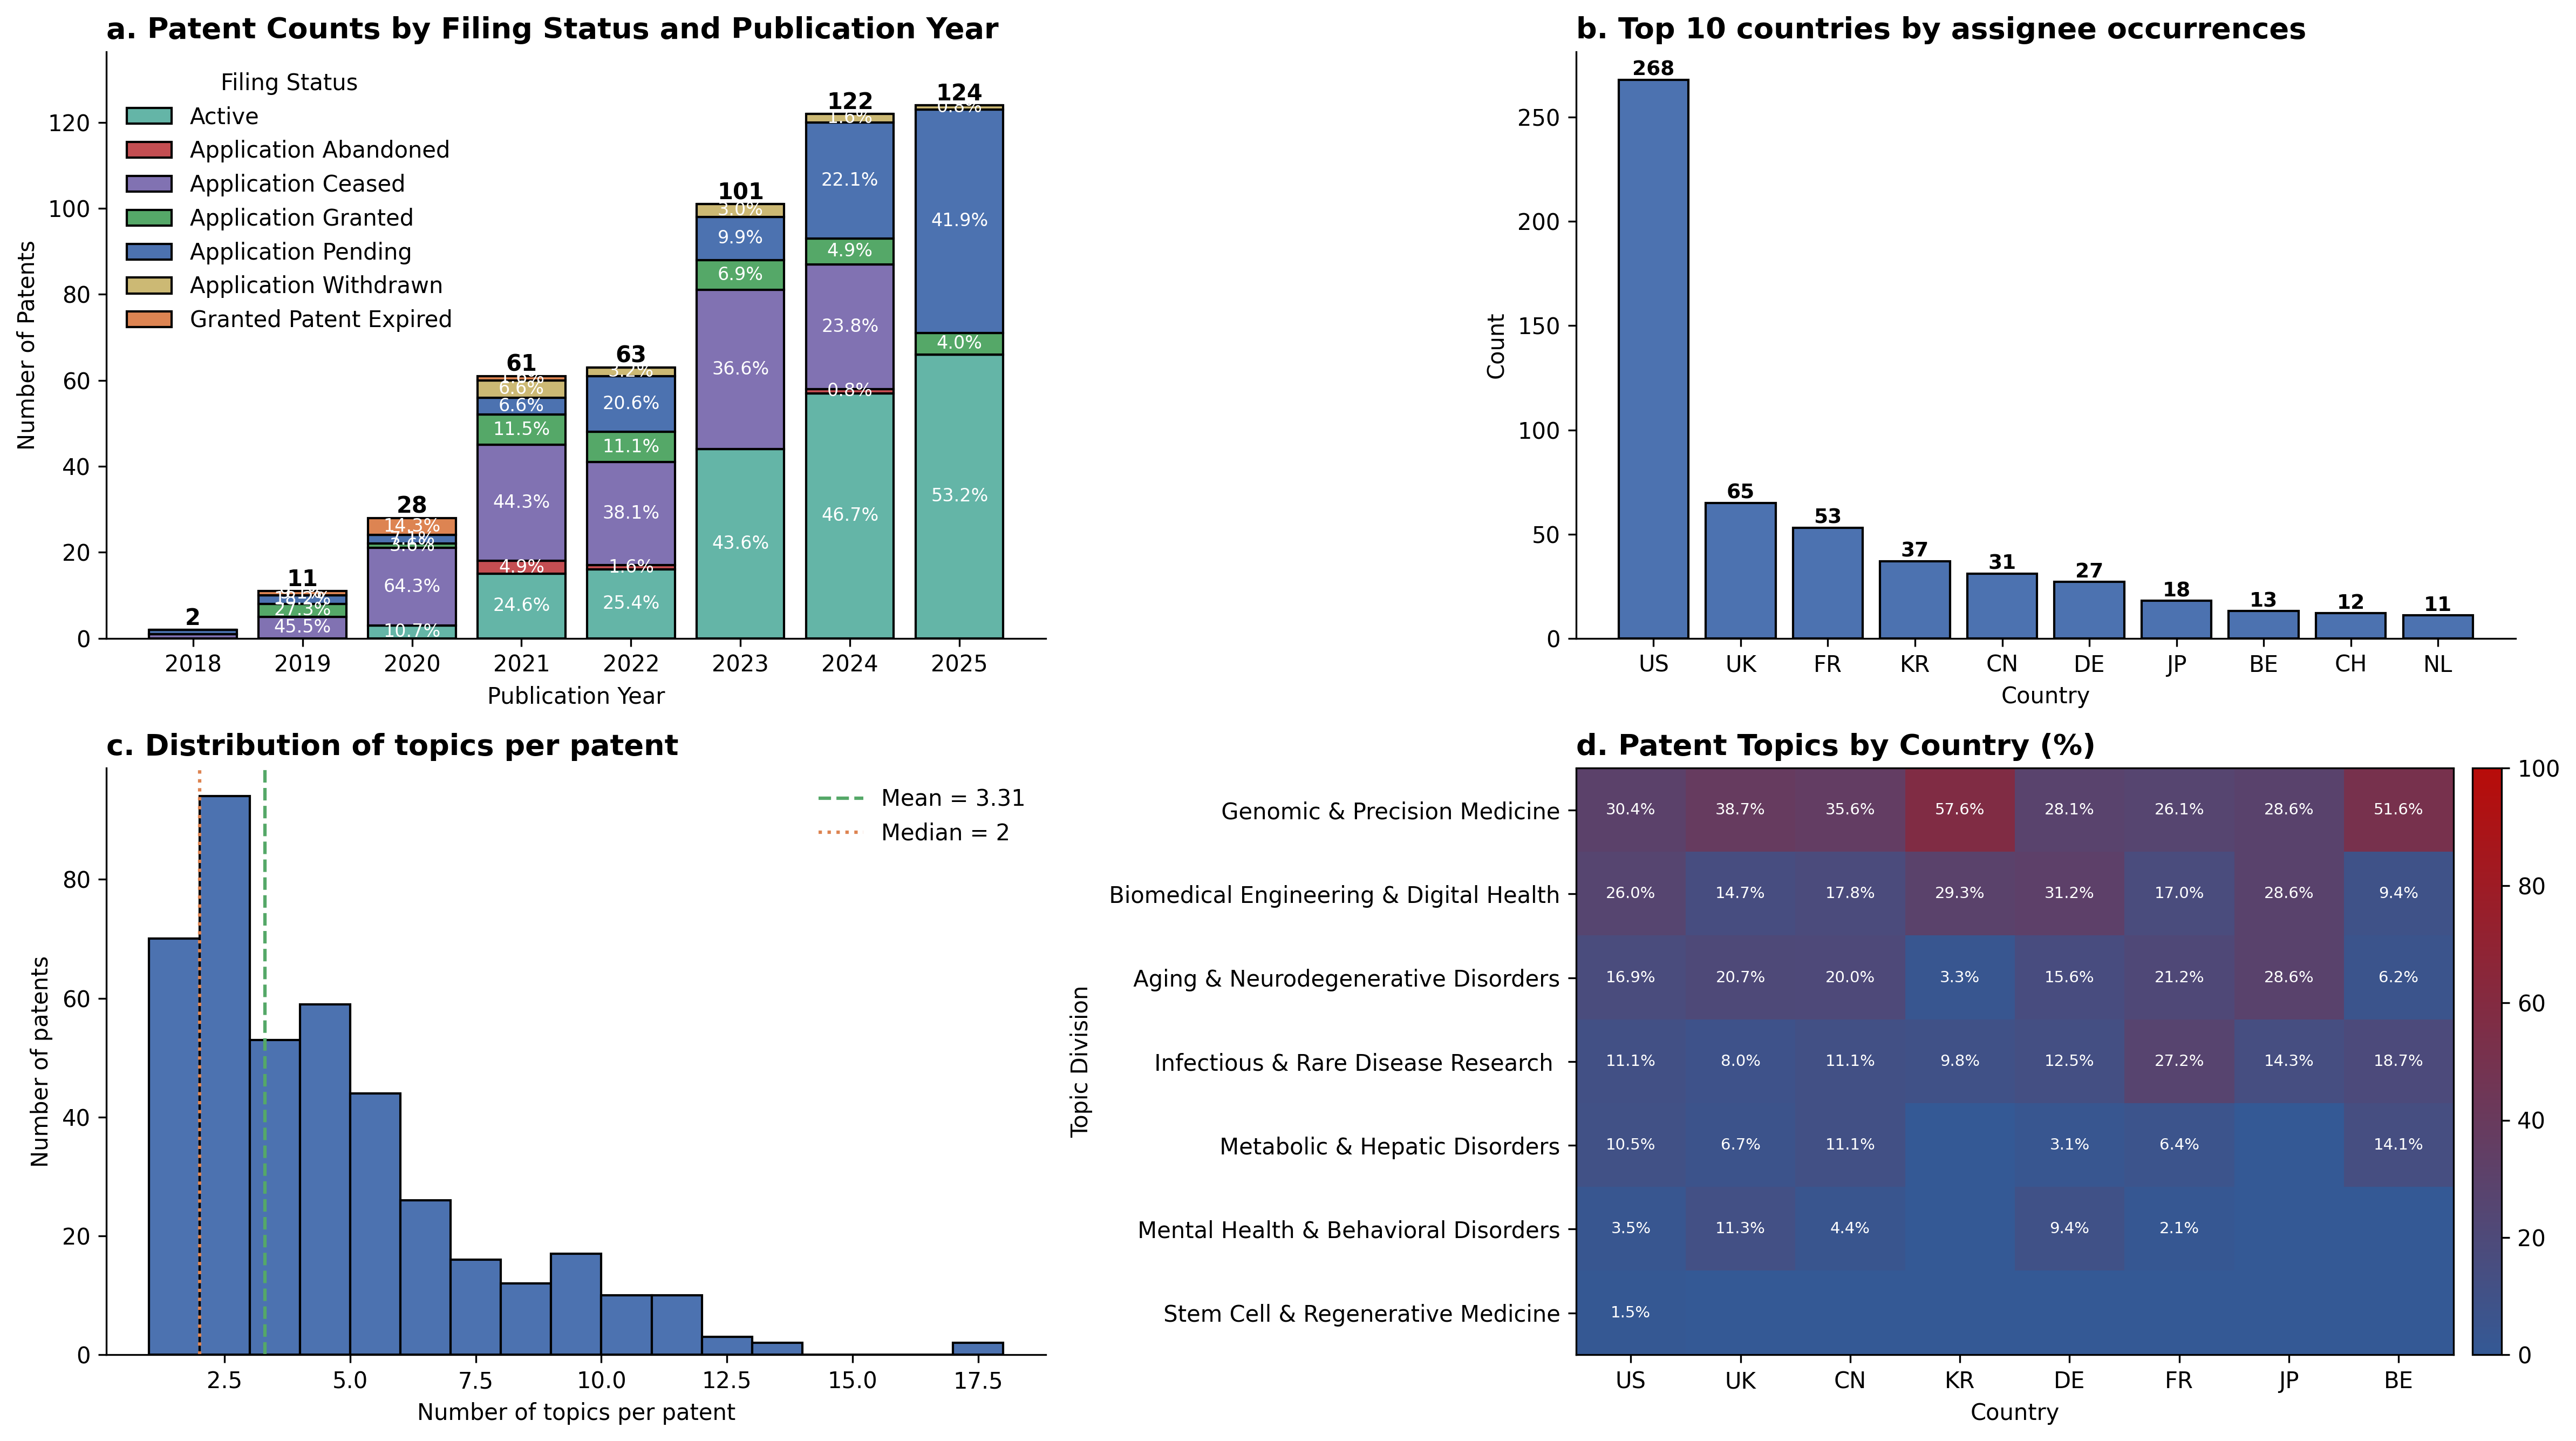

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# (a) Patent counts by filing status and publication year
ax = axes[0, 0]

replace_dict = {'Ceased':'Application Ceased', 'Granted':'Application Granted', 'Pending':'Application Pending', 'Withdrawn':'Application Withdrawn','Abandoned':'Application Abandoned','Expired - Fee Related':'Granted Patent Expired'}
df_patent['legal_status_replaced'] = df_patent['legal_status'].replace(replace_dict)


col = 'legal_status_replaced'
# ensure datetime
df_patent['publication_date'] = pd.to_datetime(
    df_patent['publication_date'], errors='coerce'
)
df_patent['publication_year'] = df_patent['publication_date'].dt.year

status_colors = {
    "Application Pending":"#4C72B0" ,        # teal (from screenshot)
    "Application Ceased": "#8172B2",         # purple (from screenshot)
    "Active":"#64B5A7"   ,                     # blue (from screenshot)
    "Application Withdrawn": "#CCB974",      # mustard (from screenshot)
    "Granted Patent Expired": "#DD8452",     # soft orange
    "Application Granted": "#55A868",        # green
    "Application Abandoned": "#C44E52"       # muted red
}

# group
filing_status_yearly = (
    df_patent
    .groupby(['publication_year', col])
    .size()
    .reset_index(name='counts')
)

# pivot for stacking
pivot_df = filing_status_yearly.pivot(
    index='publication_year',
    columns=col,
    values='counts'
).fillna(0)

pivot_df = pivot_df.sort_index()

# totals per year
totals = pivot_df.sum(axis=1)


bottom = None
for status in pivot_df.columns:
    values = pivot_df[status]
    bars = ax.bar(
        pivot_df.index,
        values,
        bottom=bottom,
        label=status,
        color=status_colors.get(status, '#999999'),
        edgecolor='black',
        linewidth=1
    )

    for year, bar, value in zip(pivot_df.index, bars, values):
        # for the top label of each bar, put the annotation outside the bar and black 
        pct = value / totals.loc[year] * 100
        loc = bar.get_height() + (bottom[year] if bottom is not None else 0)
        loc_top = True if totals.loc[year] - loc < totals.loc[year] * 0.05 else False
        
        
        if totals.loc[year] > 2 and value>0 :
            
            ax.text(
                year,
                bar.get_height() / 2 + (bottom[year] if bottom is not None else 0),
                f'{pct:.1f}%',
                 ha='center',
                 va='center',
                 fontsize=8,
                 color='white'
            )
        

    bottom = values if bottom is None else bottom + values

for year in pivot_df.index:
    ax.text(year, totals.loc[year], f'{int(totals.loc[year])}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Publication Year')
ax.set_ylabel('Number of Patents')
ax.set_title('a. Patent Counts by Filing Status and Publication Year', fontsize=title_fontsize, fontweight='bold', loc='left')
ax.legend(title='Filing Status', frameon=False, loc='upper left')
ax.set_ylim(0, totals.max() * 1.1 if len(totals) else 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# (b) Top countries by assignee occurrences
ax = axes[0, 1]
counts_df = country_df[['iso2', 'count']].copy()
counts_df.replace({'iso2': {'GB': 'UK'}}, inplace=True)
top_n = 10
df_top = counts_df.sort_values('count', ascending=False).head(top_n).copy()
ax.bar(df_top['iso2'], df_top['count'], color='#4C72B0', edgecolor='black', linewidth=1)
for _, row in df_top.iterrows():
    ax.text(row['iso2'], row['count'], f"{row['count']}", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Count')
ax.set_title(f"b. Top {min(top_n, len(df_top))} countries by assignee occurrences", fontsize=title_fontsize, fontweight='bold', loc='left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# (c) Distribution of topics per patent
ax = axes[1, 0]
topic_max = int(df_patent['n_topics'].max()) if len(df_patent) else 1
ax.hist(df_patent['n_topics'], bins=range(1, topic_max + 2), edgecolor='black', color='#4C72B0')
ax.axvline(avg_topics, linestyle='--', label=f'Mean = {avg_topics:.2f}', color='#55A868')
ax.axvline(median_topics, linestyle=':', label=f'Median = {median_topics:.0f}', color='#DD8452')
ax.legend(frameon=False)
ax.set_xlabel('Number of topics per patent')
ax.set_ylabel('Number of patents')
ax.set_title('c. Distribution of topics per patent', fontsize=title_fontsize, fontweight='bold', loc='left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# (d) Country-topic heatmap
ax = axes[1, 1]
pivot_normalized = pivot_country_topic.div(pivot_country_topic.sum(axis=0), axis=1).fillna(0) * 100
cmap = LinearSegmentedColormap.from_list('custom_cmap', [colors_scheme[3], colors_scheme[0]])
im = ax.imshow(pivot_normalized.values, cmap=cmap, aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(len(pivot_normalized.columns)))
ax.set_yticks(range(len(pivot_normalized.index)))
ax.set_xticklabels(pivot_normalized.columns, rotation=0, ha='center')

y_ticklabels = [f" {topcode_to_label.get(code, code)}" for code in pivot_normalized.index]

y_ticklabels = [x.replace("/ ","").lower() for x in y_ticklabels]
if cat_col == 'ipcr':
    y_ticklabels = [topic_short_names_2.get(label[1:], label) for label in y_ticklabels]
else:
    y_ticklabels = [code.title() for code in y_ticklabels]
ax.set_yticklabels(y_ticklabels)

for i in range(len(pivot_normalized.index)):
    for j in range(len(pivot_normalized.columns)):
        val = pivot_normalized.values[i, j]
        if val > 0:
            ax.text(j, i, f'{val:.1f}%', ha='center', va='center', color='white', fontsize=7)

ax.set_title('d. Patent Topics by Country (%)', fontsize=title_fontsize, fontweight='bold', loc='left')
ax.set_xlabel('Country')
ax.set_ylabel('Topic Division')
cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02, fraction=0.046)
cbar.set_label('', rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig('../fig/patent_overview.png', dpi=400)

## Reading the Figures
- Plot (a) compares annual patent volume and status composition; percentages inside bars show within-year composition.
- Plot (b) highlights concentration of assignee activity by country. Note that assignee is the entity that holds the patent, which may differ from the inventor's country of residence.
- Plot (c) shows how multi-topic patents are distributed and whether the portfolio is mostly narrow or broad in IPC (International Patent Classification) coverage.
- Plot (d) compares top level topic composition across countries after normalizing each country column to 100%.

### Notes of the rcdc category mapping: 
    
the original rcdc category mapping can be found at https://grants.nih.gov/funding/explore-data-on-funded-projects/rcdc-categories-at-a-glance

in this work we try to derive the top level topic (macro categories in plot d) based on Co-occurrence of the original rcdc catgegories to build a Weighted Label Network, and then using the Louvain Community Detection to derive the macro categories. 

# Additional information of the jurisdiction distribution in the dataset

In [9]:
df_patent['jurisdiction'].value_counts()

jurisdiction
US    210
WO    192
CN     37
EP     35
KR     24
JP      9
GB      2
AU      2
DE      1
LU      1
Name: count, dtype: int64